In [1]:
import re
import sys
import os
import cv2
import numpy as np

from marsneuralzoo.models.e2emvm import E2emvm
from marsneuralzoo.models.yolo_seg import SegmentationYolo

In [2]:
e2emvm = E2emvm(multiview=False)
seg_yo = SegmentationYolo()

Loaded SuperPoint model


In [3]:
debug_path = './cache/debug'
folders = os.listdir(debug_path)


cam_idx_to_image = {}
for folder in folders:

    folder_path = os.path.join(debug_path, folder)
    files = os.listdir(folder_path)
    files.sort(key=lambda x: os.path.splitext(x)[0])
    images = []

    for file in files:
        image = cv2.imread(os.path.join(folder_path, file))
        images.append(image)

    cam_idx_to_image[int(folder)] = images

In [4]:
folders

['6', '2', '4']

In [5]:
from dataengine.generator.obstacle.mask import (
    remove_overlapped_area,
)

cam_idx_to_segs = {}

for idx, images in cam_idx_to_image.items():
    segss = []
    seg_results_list = seg_yo.segment_batch(images)

    for seg_results in seg_results_list:
        masks = seg_results['masks']
        confs = seg_results['scores']
        masks = remove_overlapped_area(masks, confs)
        segss.append(masks)

    cam_idx_to_segs[int(idx)] = segss

Loading /media/vol/shared/obstacle/models/yolosegment/best.torchscript for TorchScript inference...


In [6]:
real_idx0, real_idx1 = (2, 4)
idx0 = 0
idx1 = 1

In [7]:
from dataengine.generator.obstacle.segment_tracker import (
    SegmentTracker,
    SegmentTracklet,
)
from itertools import count

_cam_to_trl_ids_dict = {}
_trl_id_to_trl_dict = {}
SegmentTracklet.id_counter = count(0)

tracker0 = SegmentTracker(idx0, _trl_id_to_trl_dict)
tracker1 = SegmentTracker(idx1, _trl_id_to_trl_dict)

timestamp = 140

images0 = cam_idx_to_image[real_idx0]
segs_list0 = cam_idx_to_segs[real_idx0]

for image, segs in zip(images0, segs_list0):
    _cam_to_trl_ids_dict[timestamp] = {}
    curr_tracklet_ids = tracker0.track(timestamp, image, segs)
    _cam_to_trl_ids_dict[timestamp][idx0] = curr_tracklet_ids
    timestamp += 1


timestamp = 140

images1 = cam_idx_to_image[real_idx1]
segs_list1 = cam_idx_to_segs[real_idx1]

for image, segs in zip(images1, segs_list1):
    curr_tracklet_ids = tracker1.track(timestamp, image, segs)
    _cam_to_trl_ids_dict[timestamp][idx1] = curr_tracklet_ids

    timestamp += 1

kj/filesystem-disk-unix.c++:1690: warning: PWD environment variable doesn't match current directory; pwd = /home/mars


In [8]:
from marsdataio.npyrenderer.renderer import generate_colors

_random_colors = generate_colors()

In [9]:
from dataengine.generator.obstacle.debug_utils import draw_mask

import torch
from lapsolver import solve_dense

_minimum_matched_kpt_count = 4

timestamp = 140

segment_id_pair = []

for image0, image1 in zip(images0, images1):

    images = [image0, image1]
    torch_images, features = e2emvm.extract_features(images)
    preds = e2emvm(torch_images, features)
    all_matches = preds['matches']

    # segment ids when keypoints are projected into id_image
    kpt_seg_ids = []
    undistorted_kpts_list = []

    for cam_idx, kpts in enumerate(features['keypoints']):
        kpts = kpts.cpu().numpy().astype(np.float32)
        seg_ids = np.full(kpts.shape[0], -1, dtype=int)

        shape = images[0].shape[:2]
        id_image = np.full(shape, -1.0, dtype=np.float32)

        tracked_trl_ids = _cam_to_trl_ids_dict[timestamp][cam_idx]
        for id in tracked_trl_ids:
            seg_trl = _trl_id_to_trl_dict[id]
            seg = seg_trl.query_segment_mask(timestamp, cam_idx)
            id_image[seg > 0] = id

        for idx, kpt in enumerate(kpts):
            x, y = kpt.astype(int)
            seg_id = id_image[y, x]
            if seg_id >= 0:
                seg_ids[idx] = seg_id

        kpt_seg_ids.append(seg_ids)

        kpts = kpts.reshape(-1, 1, 2)

    for idx0, idx1 in preds['indices_pairs']:
        key = f'{idx0}_{idx1}'

        matches = all_matches[f'matches{idx0}_{key}'][0].cpu().numpy()
        confs = all_matches[f'conf_scores_{key}'][0, :, 0].cpu().numpy()

        seg_ids0 = kpt_seg_ids[idx0]
        seg_ids1 = kpt_seg_ids[idx1]

        valid_indices = np.flatnonzero(
            (matches >= 0) & (confs >= 0.02) & (seg_ids0 >= 0)
        )
        kpts0 = features['keypoints'][idx0].cpu().numpy()
        kpts1 = features['keypoints'][idx1].cpu().numpy()

        kpts0 = kpts0[valid_indices]
        seg_ids0 = seg_ids0[valid_indices]

        kpts1_idx = matches[valid_indices]
        kpts1 = kpts1[kpts1_idx]
        seg_ids1 = seg_ids1[kpts1_idx]

        valid_indices = np.flatnonzero(seg_ids1 >= 0)

        kpts0 = kpts0[valid_indices]
        seg_ids0 = seg_ids0[valid_indices]

        kpts1 = kpts1[valid_indices]
        seg_ids1 = seg_ids1[valid_indices]

        unique_ids0 = np.unique(seg_ids0.flatten())
        unique_ids1 = np.unique(seg_ids1.flatten())

        id_idx0 = {}
        for idx, id in enumerate(unique_ids0):
            id_idx0[id] = idx

        id_idx1 = {}
        for idx, id in enumerate(unique_ids1):
            id_idx1[id] = idx

        rows = unique_ids0.shape[0]
        cols = unique_ids1.shape[0]

        # construct hit matrix to get best match
        hit_mat = np.zeros((rows, cols))

        for id0, id1 in zip(seg_ids0, seg_ids1):
            r = id_idx0[id0]
            c = id_idx1[id1]
            hit_mat[r, c] += 1

        # reject match when more than two segments are mached with one segment
        for i in range(hit_mat.shape[0]):
            if np.sum(hit_mat[i] > _minimum_matched_kpt_count) > 1:
                hit_mat[i] = 0

        for j in range(hit_mat.shape[1]):
            if np.sum(hit_mat[:, j] > _minimum_matched_kpt_count) > 1:
                hit_mat[:, j] = 0

        matched_indices = np.array(solve_dense(-hit_mat)).T

        matches = []
        for m in matched_indices:
            if hit_mat[m[0], m[1]] > _minimum_matched_kpt_count:

                seg_id0 = unique_ids0[m[0]]
                seg_id1 = unique_ids1[m[1]]

                seg0 = _trl_id_to_trl_dict[seg_id0].query_segment_mask(
                    timestamp, 0
                )
                seg1 = _trl_id_to_trl_dict[seg_id1].query_segment_mask(
                    timestamp, 1
                )

                seg0_area = np.sum(seg0)
                seg1_area = np.sum(seg1)

                score0 = float(hit_mat[m[0], m[1]] / seg0_area,)
                score1 = float(hit_mat[m[0], m[1]] / seg1_area,)

                score = score0 * score1
                # if score1 < score0:
                    # score = score1

                matches.append(
                    (
                        timestamp,
                        unique_ids0[m[0]],
                        unique_ids1[m[1]],
                        score,
                        score,
                    )
                )

        segment_id_pair += matches

        image0 = image0.copy()
        image1 = image1.copy()

        for i, (_, id0, id1, _, _) in enumerate(matches):
            seg0 = _trl_id_to_trl_dict[id0]
            mask0 = seg0.query_segment_mask(timestamp, idx0)
            draw_mask(image0, mask0, i, 0.8)
            seg1 = _trl_id_to_trl_dict[id1]
            mask1 = seg1.query_segment_mask(timestamp, idx1)
            draw_mask(image1, mask1, i, 0.8)

        stitched_img = np.concatenate([image0, image1], axis=1)
        vis_img = stitched_img.copy()

        vis_lines = np.concatenate([kpts0, kpts1], axis=1).astype(np.int32)
        vis_lines[:, 2] += image0.shape[1]

        for i, line in enumerate(vis_lines):
            c = _random_colors[i % len(_random_colors)]
            line = line.tolist()
            pt1, pt2 = (line[0], line[1]), (line[2], line[3])
            cv2.line(vis_img, pt1, pt2, color=c, lineType=cv2.LINE_AA)
            cv2.circle(vis_img, pt1, radius=4, color=c, lineType=cv2.LINE_AA)
            cv2.circle(vis_img, pt2, radius=4, color=c, lineType=cv2.LINE_AA)
        cv2.putText(
            vis_img,
            f"{timestamp}",
            (40, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 255),
            1,
            cv2.LINE_AA,
        )
        cv2.imwrite(f"debug_output/{timestamp}.png", vis_img)

    del torch_images, features, preds
    torch.cuda.empty_cache()
    timestamp += 1

In [10]:
segment_id_pair


[(140, 2, 55, 4.450009653636454e-08, 4.450009653636454e-08),
 (141, 2, 55, 2.9573124745240732e-08, 2.9573124745240732e-08),
 (142, 2, 55, 8.590412420752244e-08, 8.590412420752244e-08),
 (143, 2, 55, 1.4189989850571062e-08, 1.4189989850571062e-08),
 (144, 2, 55, 6.112735628820999e-09, 6.112735628820999e-09),
 (150, 0, 55, 1.3021160096633215e-08, 1.3021160096633215e-08),
 (151, 0, 55, 3.6867742991020124e-08, 3.6867742991020124e-08),
 (152, 0, 55, 2.1411101717415054e-08, 2.1411101717415054e-08),
 (153, 0, 56, 3.418702474416631e-06, 3.418702474416631e-06),
 (154, 0, 55, 3.268051007317292e-08, 3.268051007317292e-08),
 (156, 0, 56, 2.8190595755879017e-06, 2.8190595755879017e-06),
 (157, 0, 56, 1.7150348132588857e-06, 1.7150348132588857e-06),
 (158, 0, 56, 1.122734689793317e-06, 1.122734689793317e-06),
 (159, 0, 56, 1.3966533724609839e-06, 1.3966533724609839e-06),
 (160, 0, 56, 6.576803726003592e-07, 6.576803726003592e-07),
 (161, 0, 56, 1.8989722545855129e-06, 1.8989722545855129e-06),
 (162,

In [11]:
id0_to_id1_to_socre = {}
id1_to_id0_to_socre = {}

for timestamp, id0, id1, score0, score1 in segment_id_pair:
    id1_to_score = id0_to_id1_to_socre.setdefault(id0, {})
    curr_score = id1_to_score.setdefault(id1, 0)

    if score1 > curr_score:
        curr_score = score1
        id1_to_score[id1] = curr_score

    id0_to_score = id1_to_id0_to_socre.setdefault(id1, {})
    curr_score = id0_to_score.setdefault(id0, 0)

    if score0 > curr_score:
        curr_score = score0
        id0_to_score[id0] = curr_score

for id0, id1_to_score in id0_to_id1_to_socre.items():
    # if len(id1_to_score) > 1:
    print(f"============{id0} id0 to id1==============")
    for id1, score in id1_to_score.items():
        print(f"{id1} {score}")

for id1, id0_to_score in id1_to_id0_to_socre.items():
    # if len(id0_to_score) > 1:
    print(f"============{id1} id1 to id0==============")
    for id0, score in id0_to_score.items():
        print(f"{id0} {score}")

# segment_id_pair

============2 id0 to id1==============
55 8.590412420752244e-08
============0 id0 to id1==============
55 3.6867742991020124e-08
56 3.418702474416631e-06
============1 id0 to id1==============
58 1.312307840637621e-05
============55 id1 to id0==============
2 8.590412420752244e-08
0 3.6867742991020124e-08
============56 id1 to id0==============
0 3.418702474416631e-06
============58 id1 to id0==============
1 1.312307840637621e-05


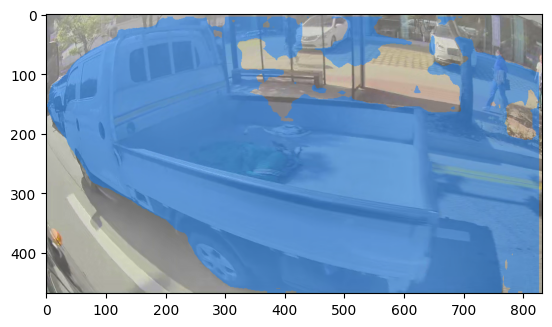

: 

In [12]:
from dataengine.generator.obstacle.debug_utils import draw_mask

debug_idx = 0
temp = images1[debug_idx].copy()
for idx, seg in enumerate(segs_list1[debug_idx]):
    draw_mask(temp, seg, idx, 0.5)

import matplotlib.pyplot as plt

plt.imshow(temp)